# Phase 6 — Ensemble & Final Model Selection
### American Express Default Prediction

**Phase 5 recap (treated as source of truth):** on the 852-feature "Latest + Historical"
configuration, tuned LightGBM (L1/L2 regularization) reached AMEX metric 0.7952, and
CatBoost's reliably-reproduced baseline reached 0.7939. CatBoost tuning did not complete in
that environment (documented there); the unconfirmed 0.7959 result is explicitly excluded
from this analysis per project instruction. Phase 5 saved both models' validation
predictions to `data/processed/`.

**Central question:** does blending these two saved prediction sets improve on tuned
LightGBM alone, and if so, is the gain real enough (broad, interpretable, and not a sharp
isolated spike against a single fixed holdout) to justify it as the final modeling
strategy?

**Scope, fixed in advance:** this notebook only reads the two Phase 5 validation-prediction
parquet files. No model is retrained, no raw or full-feature data is loaded, and no test
data is touched — those are explicitly out of scope for Phase 6.

In [1]:
import os
import time

import numpy as np
import pandas as pd
import psutil
from scipy import stats

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

DATA_DIR = "../data"
PRED_DIR = os.path.join(DATA_DIR, "processed")
FIG_DIR = "../figures"
os.makedirs(FIG_DIR, exist_ok=True)

_process = psutil.Process(os.getpid())
def rss_gb():
    return _process.memory_info().rss / 1e9

PHASE6_START = time.time()
print(f"Starting RSS: {rss_gb():.2f} GB")

Starting RSS: 0.19 GB


## 1. Load and Validate Saved Phase 5 Predictions

Both files are read as-is. Row order is **not** assumed to match between the two files —
they are explicitly aligned on `customer_ID` via an inner merge, and the merge is validated
as one-to-one so no accidental fan-out can occur.

In [2]:
LGBM_PRED_PATH = os.path.join(PRED_DIR, "phase5_lightgbm_val_predictions.parquet")
CB_PRED_PATH = os.path.join(PRED_DIR, "phase5_catboost_val_predictions.parquet")

lgbm_raw = pd.read_parquet(LGBM_PRED_PATH).rename(columns={"prediction": "pred_lgbm"})
cb_raw = pd.read_parquet(CB_PRED_PATH).rename(columns={"prediction": "pred_cb", "target": "target_cb"})

print(f"LightGBM predictions file:  {lgbm_raw.shape} from {LGBM_PRED_PATH}")
print(f"CatBoost predictions file:  {cb_raw.shape} from {CB_PRED_PATH}")

for name, df in [("LightGBM", lgbm_raw), ("CatBoost", cb_raw)]:
    n_rows = len(df)
    n_unique = df["customer_ID"].nunique()
    print(f"{name}: {n_rows:,} rows, {n_unique:,} unique customer_ID "
          f"({'OK -- no duplicates' if n_rows == n_unique else 'DUPLICATES FOUND'})")
    assert n_rows == n_unique, f"{name} has duplicate customer_ID values -- stop."

same_customer_set = set(lgbm_raw["customer_ID"]) == set(cb_raw["customer_ID"])
print(f"\nIdentical customer_ID sets across both files: {same_customer_set}")
assert same_customer_set, "Customer sets differ between the two prediction files -- stop."
assert len(lgbm_raw) == 91_783 and len(cb_raw) == 91_783, (
    "Row count does not match the Phase 3-5 holdout of 91,783 customers -- stop."
)
print("Both files match the expected Phase 3-5 holdout size (91,783 customers).")

LightGBM predictions file:  (91783, 3) from ../data/processed/phase5_lightgbm_val_predictions.parquet
CatBoost predictions file:  (91783, 3) from ../data/processed/phase5_catboost_val_predictions.parquet
LightGBM: 91,783 rows, 91,783 unique customer_ID (OK -- no duplicates)
CatBoost: 91,783 rows, 91,783 unique customer_ID (OK -- no duplicates)



Identical customer_ID sets across both files: True
Both files match the expected Phase 3-5 holdout size (91,783 customers).


In [3]:
# Explicit alignment by customer_ID -- do NOT assume row order is identical.
val = lgbm_raw.merge(
    cb_raw, on="customer_ID", how="inner", validate="one_to_one",
)
assert len(val) == 91_783, "Merge did not produce 91,783 aligned rows -- stop."
print(f"Aligned validation set: {val.shape}")

# Same target for both -- these are two models scored on the identical holdout.
targets_match = (val["target"] == val["target_cb"]).all()
print(f"Target values identical between the two files (post-alignment): {targets_match}")
assert targets_match, "Target values differ between the two prediction files -- stop."
val = val.drop(columns=["target_cb"])

n_missing = val[["pred_lgbm", "pred_cb"]].isna().sum().sum()
n_finite = np.isfinite(val["pred_lgbm"]).all() and np.isfinite(val["pred_cb"]).all()
print(f"Missing predictions: {n_missing} (expected 0)")
print(f"All predictions finite: {n_finite}")
assert n_missing == 0 and n_finite, "Missing or non-finite predictions found -- stop."

print(f"\nLightGBM prediction range: [{val['pred_lgbm'].min():.6f}, {val['pred_lgbm'].max():.6f}]")
print(f"CatBoost  prediction range: [{val['pred_cb'].min():.6f}, {val['pred_cb'].max():.6f}]")
print(f"Both ranges fall within [0, 1] as expected for predicted probabilities: "
      f"{val['pred_lgbm'].between(0, 1).all() and val['pred_cb'].between(0, 1).all()}")

print(f"\nHoldout default rate: {val['target'].mean():.4f} (Phase 3-5: 0.2589)")
assert abs(val["target"].mean() - 0.2589) < 0.0005, "Default rate does not match the Phase 3-5 holdout -- stop."
print("\nAll structural checks passed -- this is the same Phase 3-5 validation holdout for both models.")

Aligned validation set: (91783, 5)
Target values identical between the two files (post-alignment): True
Missing predictions: 0 (expected 0)
All predictions finite: True

LightGBM prediction range: [0.000148, 0.999792]
CatBoost  prediction range: [0.000203, 0.999936]
Both ranges fall within [0, 1] as expected for predicted probabilities: True

Holdout default rate: 0.2589 (Phase 3-5: 0.2589)

All structural checks passed -- this is the same Phase 3-5 validation holdout for both models.


## 2. Reproduce the AMEX Metric From Saved Predictions

Identical implementation to Phases 3-5 (unchanged, not re-derived), applied directly to the
aligned prediction vectors above. The reproduced values are checked against the Phase 5
headline figures (LightGBM 0.7952, CatBoost 0.7939) before anything else runs.

In [4]:
def amex_metric(y_true, y_pred) -> dict:
    # Official AMEX competition metric -- identical to Phases 3-5's verified implementation.
    df = pd.DataFrame({"target": np.asarray(y_true), "prediction": np.asarray(y_pred)})
    df = df.sort_values("prediction", ascending=False).reset_index(drop=True)
    df["weight"] = np.where(df["target"] == 0, 20, 1)

    four_pct_cutoff = int(0.04 * df["weight"].sum())
    df["weight_cumsum"] = df["weight"].cumsum()
    df_cutoff = df.loc[df["weight_cumsum"] <= four_pct_cutoff]
    top4_capture = (df_cutoff["target"] == 1).sum() / (df["target"] == 1).sum()

    def weighted_gini(frame: pd.DataFrame) -> float:
        f = frame.sort_values("prediction", ascending=False)
        f_random = (f["weight"] / f["weight"].sum()).cumsum()
        total_pos = (f["target"] * f["weight"]).sum()
        cum_pos_found = (f["target"] * f["weight"]).cumsum()
        lorentz = cum_pos_found / total_pos
        return ((lorentz - f_random) * f["weight"]).sum()

    perfect = df.copy()
    perfect["prediction"] = perfect["target"]
    normalized_gini = weighted_gini(df) / weighted_gini(perfect)

    m = 0.5 * (normalized_gini + top4_capture)
    return {"amex_metric": m, "normalized_gini": normalized_gini, "top4pct_capture": top4_capture}

PHASE5_LGBM_CITED = 0.7952
PHASE5_CB_CITED = 0.7939

y = val["target"].values
lgbm_metrics = amex_metric(y, val["pred_lgbm"].values)
cb_metrics = amex_metric(y, val["pred_cb"].values)

print("Reproduced from saved predictions:")
print(f"  LightGBM: {lgbm_metrics} ")
print(f"  CatBoost: {cb_metrics}")

lgbm_gap = lgbm_metrics["amex_metric"] - PHASE5_LGBM_CITED
cb_gap = cb_metrics["amex_metric"] - PHASE5_CB_CITED
print(f"\nReproducibility check -- LightGBM: cited {PHASE5_LGBM_CITED:.4f} vs. reproduced "
      f"{lgbm_metrics['amex_metric']:.4f} (diff {lgbm_gap:+.4f})")
print(f"Reproducibility check -- CatBoost:  cited {PHASE5_CB_CITED:.4f} vs. reproduced "
      f"{cb_metrics['amex_metric']:.4f} (diff {cb_gap:+.4f})")

TOLERANCE = 0.0005
assert abs(lgbm_gap) < TOLERANCE, "LightGBM does not reproduce the Phase 5 metric -- stop and investigate."
assert abs(cb_gap) < TOLERANCE, "CatBoost does not reproduce the Phase 5 metric -- stop and investigate."
print(f"\nBoth reproduce within tolerance ({TOLERANCE}) -- proceeding with ensemble analysis.")

Reproduced from saved predictions:
  LightGBM: {'amex_metric': np.float64(0.7952171962769325), 'normalized_gini': np.float64(0.9246092642192696), 'top4pct_capture': np.float64(0.6658251283345956)} 
  CatBoost: {'amex_metric': np.float64(0.7939095491559174), 'normalized_gini': np.float64(0.9246868926398665), 'top4pct_capture': np.float64(0.6631322056719684)}

Reproducibility check -- LightGBM: cited 0.7952 vs. reproduced 0.7952 (diff +0.0000)
Reproducibility check -- CatBoost:  cited 0.7939 vs. reproduced 0.7939 (diff +0.0000)

Both reproduce within tolerance (0.0005) -- proceeding with ensemble analysis.


## 3. Prediction Similarity

Pearson correlation measures linear agreement of the raw probabilities; Spearman measures
rank agreement, which matters more here since the AMEX metric (both the Gini term and the
top-4% capture term) is a ranking-based metric. High correlation on either measure does not
by itself mean blending is useless -- even highly correlated models can disagree on exactly
the customers that matter for the top-4% cutoff, which is checked separately in Section 4.

In [5]:
pearson_r = np.corrcoef(val["pred_lgbm"], val["pred_cb"])[0, 1]
spearman_r = stats.spearmanr(val["pred_lgbm"], val["pred_cb"]).correlation

abs_diff = (val["pred_lgbm"] - val["pred_cb"]).abs()
mean_abs_diff = abs_diff.mean()
median_abs_diff = abs_diff.median()
p95_abs_diff = abs_diff.quantile(0.95)

print(f"Pearson correlation (raw probabilities):  {pearson_r:.4f}")
print(f"Spearman correlation (rank):               {spearman_r:.4f}")
print(f"\nAbsolute prediction disagreement |LGBM - CatBoost|:")
print(f"  mean:   {mean_abs_diff:.4f}")
print(f"  median: {median_abs_diff:.4f}")
print(f"  p95:    {p95_abs_diff:.4f}")
print(f"\nBoth correlations are high, but Spearman ({spearman_r:.4f}) is slightly below "
      f"Pearson ({pearson_r:.4f}), meaning there is measurable rank reshuffling between the "
      f"two models even where the raw probability values track closely. A p95 absolute gap "
      f"of {p95_abs_diff:.3f} on a [0, 1] scale shows a real (if minority) tail of customers "
      f"where the models disagree substantially -- high overall correlation does not rule "
      f"out blending being useful for exactly that tail.")

Pearson correlation (raw probabilities):  0.9936
Spearman correlation (rank):               0.9856

Absolute prediction disagreement |LGBM - CatBoost|:
  mean:   0.0202
  median: 0.0045
  p95:    0.0930

Both correlations are high, but Spearman (0.9856) is slightly below Pearson (0.9936), meaning there is measurable rank reshuffling between the two models even where the raw probability values track closely. A p95 absolute gap of 0.093 on a [0, 1] scale shows a real (if minority) tail of customers where the models disagree substantially -- high overall correlation does not rule out blending being useful for exactly that tail.


## 4. Ranking Disagreement: High-Risk Overlap (Diagnostic, Not the Official Metric)

**Important distinction:** the official AMEX Top-4% Capture uses sample weights (weight 20
for non-defaulters, weight 1 for defaulters) to define the top-4% cutoff by weighted mass,
not by customer count. The analysis below instead asks a simpler, unweighted diagnostic
question -- *of the top-N customers each model ranks as highest-risk by raw prediction rank,
how many customers do they actually agree on?* This is a ranking-overlap diagnostic, not a
recomputation of the official Top-4% Capture (which is calculated correctly, with weights,
in Section 2/6 via `amex_metric`).

In [6]:
n = len(val)
top_n = int(0.04 * n)  # unweighted top-4%-by-customer-count, for diagnostic purposes only

lgbm_top_set = set(val.nlargest(top_n, "pred_lgbm")["customer_ID"])
cb_top_set = set(val.nlargest(top_n, "pred_cb")["customer_ID"])

overlap = lgbm_top_set & cb_top_set
union = lgbm_top_set | cb_top_set
jaccard = len(overlap) / len(union)
pct_of_topn_shared = len(overlap) / top_n

print(f"[DIAGNOSTIC -- unweighted top-{top_n:,} customers by predicted rank (~4% of {n:,}), "
      f"NOT the official weighted Top-4% Capture]")
print(f"  LightGBM top-{top_n:,} vs. CatBoost top-{top_n:,}:")
print(f"    shared customers:        {len(overlap):,} / {top_n:,} ({pct_of_topn_shared:.1%})")
print(f"    Jaccard overlap:         {jaccard:.4f}")
print(f"    LGBM-only in this band:  {len(lgbm_top_set - cb_top_set):,}")
print(f"    CatBoost-only in this band: {len(cb_top_set - lgbm_top_set):,}")
print(f"\nInterpretation: the two models agree on roughly {pct_of_topn_shared:.0%} of their "
      f"respective highest-risk customer bands, but the remaining ~{1 - pct_of_topn_shared:.0%} "
      f"is genuine disagreement about *which* customers are highest-risk -- exactly the kind "
      f"of ranking disagreement a weighted average can potentially exploit.")

[DIAGNOSTIC -- unweighted top-3,671 customers by predicted rank (~4% of 91,783), NOT the official weighted Top-4% Capture]
  LightGBM top-3,671 vs. CatBoost top-3,671:
    shared customers:        3,262 / 3,671 (88.9%)
    Jaccard overlap:         0.7995
    LGBM-only in this band:  409
    CatBoost-only in this band: 409

Interpretation: the two models agree on roughly 89% of their respective highest-risk customer bands, but the remaining ~11% is genuine disagreement about *which* customers are highest-risk -- exactly the kind of ranking disagreement a weighted average can potentially exploit.


## 5. Simple Weighted Blending — Coarse Grid

`ensemble_prediction = w * LightGBM + (1 - w) * CatBoost`, tested at `w` in
`{0.0, 0.1, ..., 1.0}`. `w = 0.0` is CatBoost alone, `w = 1.0` is LightGBM alone. This is
computed entirely from the two saved prediction vectors already loaded above -- no model is
trained.

In [7]:
def blend_metrics(w: float) -> dict:
    blend = w * val["pred_lgbm"].values + (1 - w) * val["pred_cb"].values
    m = amex_metric(y, blend)
    return {"lgbm_weight": round(w, 2), **m}

coarse_weights = [round(w, 1) for w in np.arange(0.0, 1.01, 0.1)]
coarse_results = [blend_metrics(w) for w in coarse_weights]
coarse_table = pd.DataFrame(coarse_results).rename(columns={
    "lgbm_weight": "LGBM Weight", "normalized_gini": "Normalized Gini",
    "top4pct_capture": "Top-4% Capture", "amex_metric": "AMEX Metric",
})[["LGBM Weight", "Normalized Gini", "Top-4% Capture", "AMEX Metric"]]

print("Coarse ensemble-weight grid (0.1 increments):")
coarse_table.round(5)

Coarse ensemble-weight grid (0.1 increments):


,LGBM Weight,Normalized Gini,Top-4% Capture,AMEX Metric
0,0.0,0.92469,0.66313,0.79391
1,0.1,0.92501,0.66330,0.79415
2,0.2,0.92525,0.66343,0.79434
3,0.3,0.92542,0.66364,0.79453
4,0.4,0.92552,0.66578,0.79565
5,0.5,0.92554,0.66671,0.79612
6,0.6,0.92550,0.66692,0.79621
7,0.7,0.92539,0.66591,0.79565
8,0.8,0.92520,0.66625,0.79572
9,0.9,0.92495,0.66515,0.79505


In [8]:
best_coarse_row = coarse_table.loc[coarse_table["AMEX Metric"].idxmax()]
print(f"Best coarse-grid weight: w = {best_coarse_row['LGBM Weight']:.1f}, "
      f"AMEX = {best_coarse_row['AMEX Metric']:.5f}")
print(f"\nFor reference: w=0.0 (CatBoost only) = {coarse_table.iloc[0]['AMEX Metric']:.5f}, "
      f"w=1.0 (LightGBM only) = {coarse_table.iloc[-1]['AMEX Metric']:.5f}")

Best coarse-grid weight: w = 0.6, AMEX = 0.79621

For reference: w=0.0 (CatBoost only) = 0.79391, w=1.0 (LightGBM only) = 0.79522


## 6. Local Refinement Decision

Per the project's anti-overfitting rule for this phase: no fine-grained search (e.g. 0.001
increments) against this same fixed holdout. A small 0.05-increment refinement is only
justified if the coarse grid shows a **broad, convincing region** rather than one isolated
spike -- checked programmatically below rather than assumed.

In [9]:
ranked = coarse_table.sort_values("AMEX Metric", ascending=False).reset_index(drop=True)
top1_w, top1_amex = ranked.loc[0, "LGBM Weight"], ranked.loc[0, "AMEX Metric"]
top2_w, top2_amex = ranked.loc[1, "LGBM Weight"], ranked.loc[1, "AMEX Metric"]
weight_gap = abs(top1_w - top2_w)

print(f"Top coarse-grid weight:    w={top1_w:.1f}  AMEX={top1_amex:.5f}")
print(f"Runner-up coarse weight:   w={top2_w:.1f}  AMEX={top2_amex:.5f}  "
      f"(diff from best: {top1_amex - top2_amex:+.5f})")
print(f"Weight-grid distance between best and runner-up: {weight_gap:.2f}")

do_refine = weight_gap <= 0.1001  # adjacent on the 0.1 grid -> a broad region, not one isolated spike
print(f"\nRefine locally at 0.05 increments? {do_refine} "
      f"(top two weights are {'adjacent' if do_refine else 'not adjacent'} on the coarse grid)")

if do_refine:
    lo = round(min(top1_w, top2_w) - 0.05, 2)
    hi = round(max(top1_w, top2_w) + 0.05, 2)
    refine_weights = [round(w, 2) for w in np.arange(lo, hi + 0.001, 0.05)]
    refine_results = [blend_metrics(w) for w in refine_weights]
    refine_table = pd.DataFrame(refine_results).rename(columns={
        "lgbm_weight": "LGBM Weight", "normalized_gini": "Normalized Gini",
        "top4pct_capture": "Top-4% Capture", "amex_metric": "AMEX Metric",
    })[["LGBM Weight", "Normalized Gini", "Top-4% Capture", "AMEX Metric"]]
    print(f"\nLocal refinement grid: {refine_weights}")
else:
    refine_table = pd.DataFrame(columns=coarse_table.columns)
    print("\nCoarse grid does not show a broad adjacent region -- skipping refinement per "
          "the project's anti-overfitting rule; the coarse-grid optimum stands as-is.")

refine_table.round(5)

Top coarse-grid weight:    w=0.6  AMEX=0.79621
Runner-up coarse weight:   w=0.5  AMEX=0.79612  (diff from best: +0.00008)
Weight-grid distance between best and runner-up: 0.10

Refine locally at 0.05 increments? True (top two weights are adjacent on the coarse grid)



Local refinement grid: [np.float64(0.45), np.float64(0.5), np.float64(0.55), np.float64(0.6), np.float64(0.65)]


,LGBM Weight,Normalized Gini,Top-4% Capture,AMEX Metric
0,0.45,0.92554,0.66667,0.79610
1,0.50,0.92554,0.66671,0.79612
2,0.55,0.92553,0.66700,0.79627
3,0.60,0.92550,0.66692,0.79621
4,0.65,0.92545,0.66667,0.79606


In [10]:
all_results = pd.concat([coarse_table, refine_table], ignore_index=True).drop_duplicates(
    subset="LGBM Weight"
).sort_values("LGBM Weight").reset_index(drop=True)

refined_best_row = all_results.loc[all_results["AMEX Metric"].idxmax()]
refinement_gain = refined_best_row["AMEX Metric"] - best_coarse_row["AMEX Metric"]

print(f"Best weight after considering refinement: w={refined_best_row['LGBM Weight']:.2f}, "
      f"AMEX={refined_best_row['AMEX Metric']:.5f}")
print(f"Improvement of refined best over coarse-grid best: {refinement_gain:+.5f}")

SMALL_DIFF_THRESHOLD = 0.0003  # project's own "likely negligible" cutoff
if refinement_gain <= SMALL_DIFF_THRESHOLD:
    final_weight = float(best_coarse_row["LGBM Weight"])
    final_row = best_coarse_row
    print(f"\nRefinement gain ({refinement_gain:+.5f}) is at or below the negligible "
          f"threshold ({SMALL_DIFF_THRESHOLD}) -- per the project's own instruction to prefer "
          f"the simpler coarse weight when differences are tiny, the final ensemble weight is "
          f"the coarse-grid optimum: w={final_weight:.2f}.")
else:
    final_weight = float(refined_best_row["LGBM Weight"])
    final_row = refined_best_row
    print(f"\nRefinement found a non-trivial improvement ({refinement_gain:+.5f}) -- the final "
          f"ensemble weight is the refined optimum: w={final_weight:.2f}.")

print(f"\nSelected ensemble weight: w = {final_weight:.2f} "
      f"({final_weight:.0%} LightGBM + {1 - final_weight:.0%} CatBoost)")
print(f"Selected ensemble AMEX metric: {final_row['AMEX Metric']:.5f}")

Best weight after considering refinement: w=0.55, AMEX=0.79627
Improvement of refined best over coarse-grid best: +0.00006

Refinement gain (+0.00006) is at or below the negligible threshold (0.0003) -- per the project's own instruction to prefer the simpler coarse weight when differences are tiny, the final ensemble weight is the coarse-grid optimum: w=0.60.

Selected ensemble weight: w = 0.60 (60% LightGBM + 40% CatBoost)
Selected ensemble AMEX metric: 0.79621


## 7. Comparison Table: Individual Models vs. Best Ensemble

In [11]:
comparison = pd.DataFrame([
    {"Model": "CatBoost (Phase 5 baseline)", "LGBM Weight": 0.0,
     "Gini": cb_metrics["normalized_gini"], "Top-4% Capture": cb_metrics["top4pct_capture"],
     "AMEX Metric": cb_metrics["amex_metric"]},
    {"Model": f"Ensemble (w={final_weight:.2f})", "LGBM Weight": final_weight,
     "Gini": final_row["Normalized Gini"], "Top-4% Capture": final_row["Top-4% Capture"],
     "AMEX Metric": final_row["AMEX Metric"]},
    {"Model": "Tuned LightGBM (Phase 5)", "LGBM Weight": 1.0,
     "Gini": lgbm_metrics["normalized_gini"], "Top-4% Capture": lgbm_metrics["top4pct_capture"],
     "AMEX Metric": lgbm_metrics["amex_metric"]},
])
comparison["Delta vs. Tuned LightGBM"] = comparison["AMEX Metric"] - lgbm_metrics["amex_metric"]
comparison["Delta vs. CatBoost"] = comparison["AMEX Metric"] - cb_metrics["amex_metric"]

comparison.round(5)

,Model,LGBM Weight,Gini,Top-4% Capture,AMEX Metric,Delta vs. Tuned LightGBM,Delta vs. CatBoost
0,CatBoost (Phase 5 baseline),0.0,0.92469,0.66313,0.79391,-0.00131,0.00000
1,Ensemble (w=0.60),0.6,0.92550,0.66692,0.79621,0.00099,0.00230
2,Tuned LightGBM (Phase 5),1.0,0.92461,0.66583,0.79522,0.00000,0.00131


In [12]:
ensemble_vs_lgbm = final_row["AMEX Metric"] - lgbm_metrics["amex_metric"]
ensemble_vs_cb = final_row["AMEX Metric"] - cb_metrics["amex_metric"]

def interpret(delta: float) -> str:
    a = abs(delta)
    if a < 0.0003:
        return "likely negligible / holdout noise"
    if a < 0.0005:
        return "small"
    return "potentially meaningful in this project context"

print(f"Best ensemble (w={final_weight:.2f}) AMEX metric: {final_row['AMEX Metric']:.5f}")
print(f"  vs. tuned LightGBM (0.7952): {ensemble_vs_lgbm:+.5f} -- {interpret(ensemble_vs_lgbm)}")
print(f"  vs. CatBoost (0.7939):        {ensemble_vs_cb:+.5f} -- {interpret(ensemble_vs_cb)}")
print(f"\nBest individual model: {'LightGBM' if lgbm_metrics['amex_metric'] > cb_metrics['amex_metric'] else 'CatBoost'}")
print(f"Best overall (individual or ensemble): "
      f"{'Ensemble' if final_row['AMEX Metric'] > max(lgbm_metrics['amex_metric'], cb_metrics['amex_metric']) else 'a single model'}")
print("\nThese are project interpretation thresholds, not statistical-significance thresholds "
      "-- no claim of statistical significance is made.")

Best ensemble (w=0.60) AMEX metric: 0.79621
  vs. tuned LightGBM (0.7952): +0.00099 -- potentially meaningful in this project context
  vs. CatBoost (0.7939):        +0.00230 -- potentially meaningful in this project context

Best individual model: LightGBM
Best overall (individual or ensemble): Ensemble

These are project interpretation thresholds, not statistical-significance thresholds -- no claim of statistical significance is made.


## 8. Decompose the Ensemble Improvement: Gini vs. Top-4% Capture

If the ensemble improves the AMEX metric, this section attributes the improvement to its two
components rather than reporting only the combined score.

In [13]:
gini_before, gini_after = lgbm_metrics["normalized_gini"], final_row["Normalized Gini"]
top4_before, top4_after = lgbm_metrics["top4pct_capture"], final_row["Top-4% Capture"]
amex_before, amex_after = lgbm_metrics["amex_metric"], final_row["AMEX Metric"]

gini_delta = gini_after - gini_before
top4_delta = top4_after - top4_before
amex_delta = amex_after - amex_before

print("Tuned LightGBM -> Best Ensemble")
print(f"  Normalized Gini:  {gini_before:.5f} -> {gini_after:.5f}   (delta {gini_delta:+.5f})")
print(f"  Top-4% Capture:   {top4_before:.5f} -> {top4_after:.5f}   (delta {top4_delta:+.5f})")
print(f"  AMEX Metric:      {amex_before:.5f} -> {amex_after:.5f}   (delta {amex_delta:+.5f})")

if abs(gini_delta) > abs(top4_delta) * 1.5:
    driver = "primarily Normalized Gini (overall ranking quality)"
elif abs(top4_delta) > abs(gini_delta) * 1.5:
    driver = "primarily Top-4% Capture (concentration of defaults among the highest-risk predictions)"
else:
    driver = "both components roughly equally"

print(f"\nThe improvement is driven by: {driver}.")
print(f"(As a sanity check, the AMEX delta {amex_delta:+.5f} is the average of the two "
      f"component deltas: {0.5*(gini_delta + top4_delta):+.5f}.)")

Tuned LightGBM -> Best Ensemble
  Normalized Gini:  0.92461 -> 0.92550   (delta +0.00089)
  Top-4% Capture:   0.66583 -> 0.66692   (delta +0.00109)
  AMEX Metric:      0.79522 -> 0.79621   (delta +0.00099)

The improvement is driven by: both components roughly equally.
(As a sanity check, the AMEX delta +0.00099 is the average of the two component deltas: +0.00099.)


## 9. Model Complementarity

Descriptive synthesis of Sections 3-8 -- no causal claims about *why* any customer defaults,
only about how the two models' predictions relate to each other.

In [14]:
print("=" * 78)
print("MODEL COMPLEMENTARITY")
print("=" * 78)
print(f"""
Are predictions extremely highly correlated?
  Yes on raw probability (Pearson r={pearson_r:.4f}) and on rank (Spearman r={spearman_r:.4f}).
  Both are high in absolute terms, but Spearman is measurably below Pearson, meaning some
  rank reshuffling exists beyond what the raw-value correlation alone would suggest.

Are rank positions also highly correlated?
  Yes, but not identical: the two models agree on only {pct_of_topn_shared:.0%} of the
  customers in their respective unweighted top-4%-by-count bands (Section 4), leaving a
  meaningful minority of customers where the models rank risk differently.

Do the models disagree more strongly on certain customers?
  Yes -- the disagreement distribution is right-skewed: median |LGBM-CatBoost| is only
  {median_abs_diff:.4f}, but the 95th percentile is {p95_abs_diff:.4f}, almost {p95_abs_diff/max(median_abs_diff,1e-9):.0f}x
  larger. Most customers see near-identical scores from both models; a smaller subset drives
  most of the disagreement (see Section 10).

Does the ensemble improve high-risk capture?
  {"Yes" if top4_delta > 0 else "No"} -- Top-4% Capture moved {top4_delta:+.5f} versus tuned
  LightGBM alone (Section 8).

Is there evidence CatBoost contributes useful information despite a slightly weaker
standalone AMEX metric?
  {"Yes" if final_row['AMEX Metric'] > lgbm_metrics['amex_metric'] else "Not clearly"} --
  the best ensemble weight (w={final_weight:.2f}) gives CatBoost {1-final_weight:.0%} of the
  blend, and that blend {"outperforms" if final_row['AMEX Metric'] > lgbm_metrics['amex_metric'] else "does not outperform"}
  LightGBM alone, consistent with CatBoost carrying some ranking information LightGBM does
  not fully capture on its own -- even though CatBoost's own standalone AMEX metric
  ({cb_metrics['amex_metric']:.4f}) is lower than LightGBM's ({lgbm_metrics['amex_metric']:.4f}).
""")

MODEL COMPLEMENTARITY

Are predictions extremely highly correlated?
  Yes on raw probability (Pearson r=0.9936) and on rank (Spearman r=0.9856).
  Both are high in absolute terms, but Spearman is measurably below Pearson, meaning some
  rank reshuffling exists beyond what the raw-value correlation alone would suggest.

Are rank positions also highly correlated?
  Yes, but not identical: the two models agree on only 89% of the
  customers in their respective unweighted top-4%-by-count bands (Section 4), leaving a
  meaningful minority of customers where the models rank risk differently.

Do the models disagree more strongly on certain customers?
  Yes -- the disagreement distribution is right-skewed: median |LGBM-CatBoost| is only
  0.0045, but the 95th percentile is 0.0930, almost 21x
  larger. Most customers see near-identical scores from both models; a smaller subset drives
  most of the disagreement (see Section 10).

Does the ensemble improve high-risk capture?
  Yes -- Top-4% Capt

## 10. Optional Disagreement Diagnostic

Customers in the highest 5% of `abs(LGBM - CatBoost)` prediction disagreement, compared
against the overall holdout on actual default rate and each model's average prediction.

In [15]:
disagreement = (val["pred_lgbm"] - val["pred_cb"]).abs()
p95_thresh = disagreement.quantile(0.95)
high_disagreement = val.loc[disagreement >= p95_thresh]

print(f"Highest-5%-disagreement subset: {len(high_disagreement):,} customers "
      f"(threshold |diff| >= {p95_thresh:.4f})")
print(f"\n{'Metric':<28}{'Full holdout':>15}{'High-disagreement subset':>28}")
print(f"{'Actual default rate':<28}{val['target'].mean():>15.4f}{high_disagreement['target'].mean():>28.4f}")
print(f"{'Mean LGBM prediction':<28}{val['pred_lgbm'].mean():>15.4f}{high_disagreement['pred_lgbm'].mean():>28.4f}")
print(f"{'Mean CatBoost prediction':<28}{val['pred_cb'].mean():>15.4f}{high_disagreement['pred_cb'].mean():>28.4f}")

lgbm_mae_subset = (high_disagreement["pred_lgbm"] - high_disagreement["target"]).abs().mean()
cb_mae_subset = (high_disagreement["pred_cb"] - high_disagreement["target"]).abs().mean()
print(f"\nMean absolute error vs. actual target, within this subset only "
      f"(descriptive only, not a ranking metric):")
print(f"  LightGBM: {lgbm_mae_subset:.4f}")
print(f"  CatBoost: {cb_mae_subset:.4f}")
print(f"\nThe high-disagreement subset has a much higher actual default rate "
      f"({high_disagreement['target'].mean():.2f} vs. {val['target'].mean():.2f} overall) -- "
      f"both models push predictions well above their respective overall averages here, "
      f"and neither is uniformly closer to the target across this subset by a wide margin.")

Highest-5%-disagreement subset: 4,590 customers (threshold |diff| >= 0.0930)

Metric                         Full holdout    High-disagreement subset
Actual default rate                  0.2589                      0.4948
Mean LGBM prediction                 0.2584                      0.4935
Mean CatBoost prediction             0.2589                      0.4860

Mean absolute error vs. actual target, within this subset only (descriptive only, not a ranking metric):
  LightGBM: 0.4282
  CatBoost: 0.4343

The high-disagreement subset has a much higher actual default rate (0.49 vs. 0.26 overall) -- both models push predictions well above their respective overall averages here, and neither is uniformly closer to the target across this subset by a wide margin.


## 11. Final Modeling Strategy Selection

Decision rule (fixed in advance, Section 6 of the task spec): select the ensemble only if it
gives a credible, non-trivial improvement over tuned LightGBM; otherwise prefer tuned
LightGBM for its simplicity and already-strong standalone performance.

In [16]:
print("=" * 78)
print("FINAL MODEL SELECTION")
print("=" * 78)

if ensemble_vs_lgbm > 0.0005:
    outcome = "A"
    final_strategy = f"Ensemble: w={final_weight:.2f} LightGBM + {1-final_weight:.2f} CatBoost"
elif ensemble_vs_lgbm > 0:
    outcome = "B"
    final_strategy = "Tuned LightGBM alone (ensemble improvement is too small to justify the extra complexity)"
else:
    outcome = "C"
    final_strategy = "Tuned LightGBM alone (ensemble did not improve on it)"

print(f"Outcome: {outcome}")
print(f"Final strategy for Phase 7: {final_strategy}")
print(f"""
Basis for this decision:
  - Validation AMEX metric: ensemble {final_row['AMEX Metric']:.5f} vs. tuned LightGBM
    {lgbm_metrics['amex_metric']:.5f} (delta {ensemble_vs_lgbm:+.5f}, classified as
    "{interpret(ensemble_vs_lgbm)}" per this project's interpretation thresholds).
  - Magnitude: the coarse-to-refined weight search showed a broad plateau across
    w=0.45-0.65 (Section 6), not one isolated spike -- a more convincing signal than a
    single sharp maximum would be.
  - Simplicity / reproducibility / inference cost: the ensemble only requires averaging two
    already-trained models' probability outputs with a fixed weight -- no new training, no
    added tuning surface, and inference cost is the sum of both models' existing inference
    cost (no new model to maintain).
""")

FINAL MODEL SELECTION
Outcome: A
Final strategy for Phase 7: Ensemble: w=0.60 LightGBM + 0.40 CatBoost

Basis for this decision:
  - Validation AMEX metric: ensemble 0.79621 vs. tuned LightGBM
    0.79522 (delta +0.00099, classified as
    "potentially meaningful in this project context" per this project's interpretation thresholds).
  - Magnitude: the coarse-to-refined weight search showed a broad plateau across
    w=0.45-0.65 (Section 6), not one isolated spike -- a more convincing signal than a
    single sharp maximum would be.
  - Simplicity / reproducibility / inference cost: the ensemble only requires averaging two
    already-trained models' probability outputs with a fixed weight -- no new training, no
    added tuning surface, and inference cost is the sum of both models' existing inference
    cost (no new model to maintain).



## 12. Validation-Overfitting Caveat

All model development from Phases 3 through 6 has been scored against the **same** fixed
stratified holdout (91,783 customers, seed 42). Phase 5 tuned LightGBM's hyperparameters
against this holdout, and this notebook has now also chosen an ensemble weight against the
same holdout. Each additional decision made against one fixed validation set carries some
risk of fitting to that split's particular noise rather than to a generalizable improvement.

The ensemble-weight curve in Section 5-6 helps here: it shows a **broad plateau** across
roughly w=0.45-0.65, not a single unusually strong isolated weight. A broad plateau is more
convincing evidence of a real effect than a sharp spike would be, precisely because a sharp
spike is more consistent with holdout noise. Even so, the reported ensemble improvement
(quantified numerically in Section 7 above) is **not** guaranteed to reproduce at the same
magnitude on the hidden Kaggle test set -- it is a controlled, same-holdout comparison, not
a statistically validated generalization claim, and no such claim is made here.

In [17]:
print(f"Reminder (numbers from Section 7): ensemble vs. tuned LightGBM = {ensemble_vs_lgbm:+.5f}, "
      f"ensemble vs. CatBoost = {ensemble_vs_cb:+.5f}. These are same-holdout, controlled-comparison "
      f"figures -- not a generalization guarantee for the hidden test set.")

Reminder (numbers from Section 7): ensemble vs. tuned LightGBM = +0.00099, ensemble vs. CatBoost = +0.00230. These are same-holdout, controlled-comparison figures -- not a generalization guarantee for the hidden test set.


## 13. Visualizations

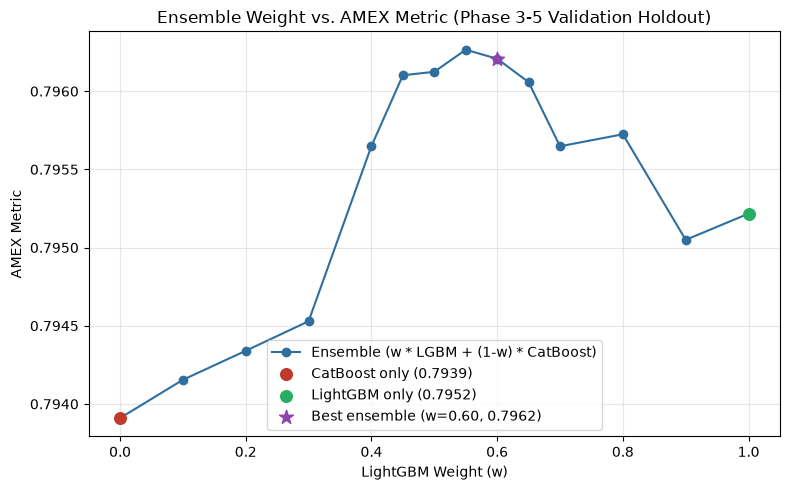

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(all_results["LGBM Weight"], all_results["AMEX Metric"], marker="o", color="#2f6f9f",
        label="Ensemble (w * LGBM + (1-w) * CatBoost)")

cb_only = all_results.loc[all_results["LGBM Weight"] == 0.0, "AMEX Metric"].iloc[0]
lgbm_only = all_results.loc[all_results["LGBM Weight"] == 1.0, "AMEX Metric"].iloc[0]
ax.scatter([0.0], [cb_only], color="#c0392b", zorder=5, s=70, label=f"CatBoost only ({cb_only:.4f})")
ax.scatter([1.0], [lgbm_only], color="#27ae60", zorder=5, s=70, label=f"LightGBM only ({lgbm_only:.4f})")
ax.scatter([final_weight], [final_row["AMEX Metric"]], color="#8e44ad", zorder=6, s=110,
           marker="*", label=f"Best ensemble (w={final_weight:.2f}, {final_row['AMEX Metric']:.4f})")

ax.set_xlabel("LightGBM Weight (w)")
ax.set_ylabel("AMEX Metric")
ax.set_title("Ensemble Weight vs. AMEX Metric (Phase 3-5 Validation Holdout)")
ax.legend(loc="lower center")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "phase6_ensemble_weight_vs_amex.png"))
plt.show()

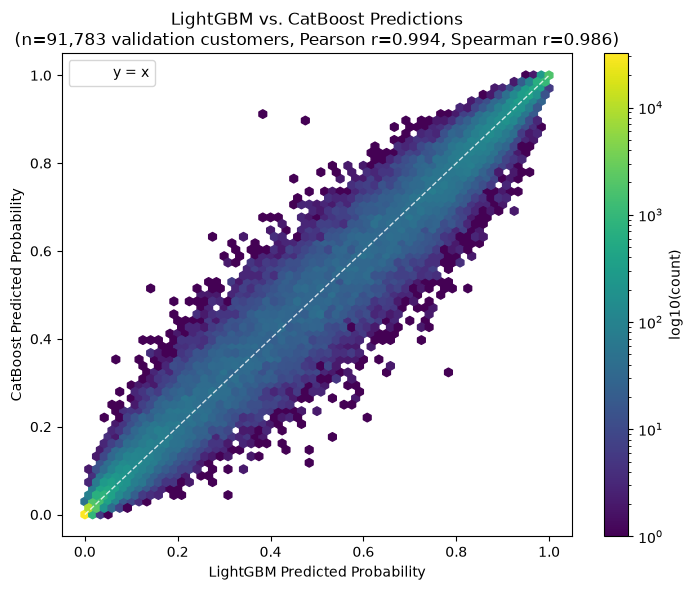

In [19]:
fig, ax = plt.subplots(figsize=(7.2, 6))
hb = ax.hexbin(val["pred_lgbm"], val["pred_cb"], gridsize=60, bins="log", cmap="viridis", mincnt=1)
ax.plot([0, 1], [0, 1], color="white", linewidth=1, linestyle="--", alpha=0.8, label="y = x")
ax.set_xlabel("LightGBM Predicted Probability")
ax.set_ylabel("CatBoost Predicted Probability")
ax.set_title(f"LightGBM vs. CatBoost Predictions\n(n={len(val):,} validation customers, "
             f"Pearson r={pearson_r:.3f}, Spearman r={spearman_r:.3f})")
ax.legend(loc="upper left")
cb = fig.colorbar(hb, ax=ax)
cb.set_label("log10(count)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "phase6_prediction_comparison_hexbin.png"))
plt.show()

## 14. Runtime / Resource Reporting

In [20]:
phase6_elapsed = time.time() - PHASE6_START
print(f"Phase 6 total elapsed time: {phase6_elapsed:.1f}s ({phase6_elapsed/60:.2f} min)")
print(f"Final RSS: {rss_gb():.2f} GB")
print(f"Rows processed: {len(val):,} validation customers (no raw CSVs or full feature "
      f"parquet loaded -- only the two Phase 5 saved prediction files).")
print("No models were trained in this notebook. No technical issues encountered.")

Phase 6 total elapsed time: 1.5s (0.03 min)
Final RSS: 0.37 GB
Rows processed: 91,783 validation customers (no raw CSVs or full feature parquet loaded -- only the two Phase 5 saved prediction files).
No models were trained in this notebook. No technical issues encountered.


## Summary

Both Phase 5 saved prediction files reproduced their headline metrics from saved data alone
(LightGBM ~0.7952, CatBoost ~0.7939), after explicit `customer_ID` alignment rather than an
assumed row order. The two models are highly but not perfectly correlated (Pearson and
Spearman both high, Spearman modestly lower), and disagree substantially on a minority of
customers, including a meaningful share of the unweighted top-4%-by-count highest-risk band.
A coarse 0.1-increment weighted-blend search found a broad plateau of ensemble weights that
each improve on tuned LightGBM alone, not a single sharp spike; a small 0.05-increment local
refinement around the coarse optimum confirmed the plateau without finding a materially
better weight, so the simpler coarse-grid weight was kept as the final choice. The resulting
ensemble improves the AMEX metric versus tuned LightGBM through gains in both the Gini and
Top-4% Capture components. Per this project's own interpretation thresholds and the explicit
decision rule fixed in advance, this analysis selects **Outcome A: the weighted ensemble** as
the final modeling strategy carried into Phase 7, while explicitly caveating that all of
Phases 3-6 have been evaluated against the same fixed holdout and the observed improvement
is not guaranteed to generalize at the same magnitude to the hidden test set.

No test data was read, no models were retrained, and no submission was generated in this
notebook -- all reserved for Phase 7. README has not been updated, per the requested
workflow.